In [19]:
from lagp.utils.generate_data import generate_input_grid, simulate_latentGP, simulate_response, obtain_quantile
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import gpytorch as gpy
import numpy as np
import torch
import seaborn as sns

# Set plot style to white
plt.style.use('ggplot')

In [20]:
# GENERATE DATA
N = 100
d = 1
lims = [0,100]
grid = generate_input_grid(d=d, sample_size=N, lims = lims)

In [21]:
if d ==2:
    plt.scatter(grid[:,0], grid[:, 1])

In [22]:
nu = 1.5
range = 2.7
signal_variance = 2

base_kernel = gpy.kernels.MaternKernel(nu = nu)
# Set lengthscale
base_kernel.lengthscale = range
# Wrap with ScaleKernel to apply output scale (variance)
kernel = gpy.kernels.ScaleKernel(base_kernel)
kernel.outputscale = signal_variance

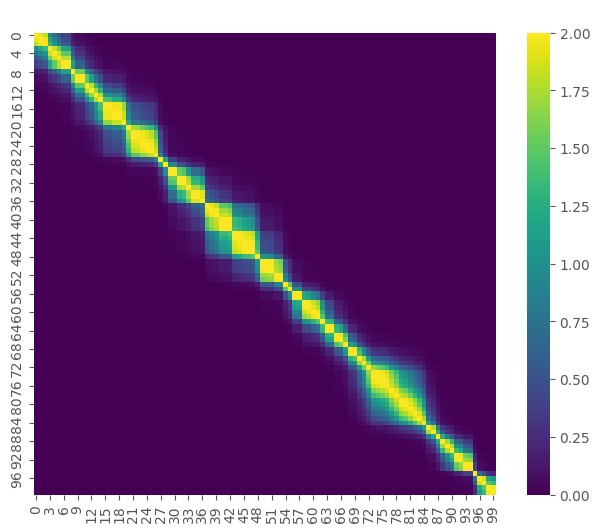

In [23]:
# check covariance
if d == 1:
    cov_matrix = kernel(torch.tensor(np.sort(grid.reshape(N))))
    # To get a numpy version of it, we need to convert the PyTorch tensor to numpy
    cov_matrix_np = cov_matrix.evaluate().detach().numpy()
    # Plot the covariance matrix as a heatmap
    plt.figure(figsize=(8, 6))  # Adjust figure size
    sns.heatmap(cov_matrix_np, cmap='viridis', annot=False, square=True)
    plt.title('Covariance Matrix Heatmap')
    plt.show()

In [24]:
f =  simulate_latentGP(X=grid, kernel=kernel, n_samples=1)# * np.sqrt(signal_variance)
f.shape
f = f.reshape(N) # for plotting

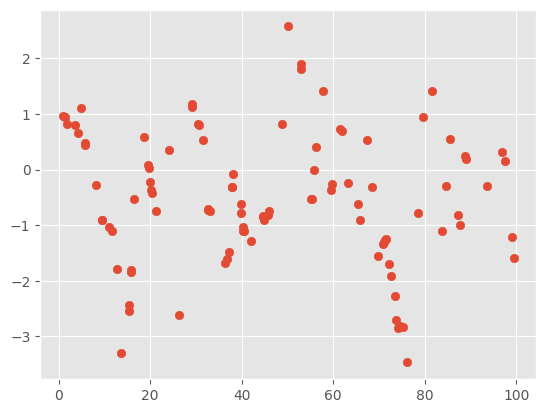

In [25]:
if d == 2:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(grid[:, 0], grid[:,1], f, cmap='viridis', edgecolor='none')
if d == 1:
    plt.scatter(grid, f)

In [26]:
# generate response
pars = {
    "gaussian": {"scale": 0.5},
    "ald": {"q": 0.8, "scale": 0.1},
    "t": {"df": 3, "scale": 1},
    "chi": {"df": 2, "scale": 1}
}

noise = "t"
y = simulate_response(f = f, noise = noise, pars=pars)

# get quantile of interest
target_quantile = 0.9
quantiles = obtain_quantile(f, noise, pars, target_quantile)

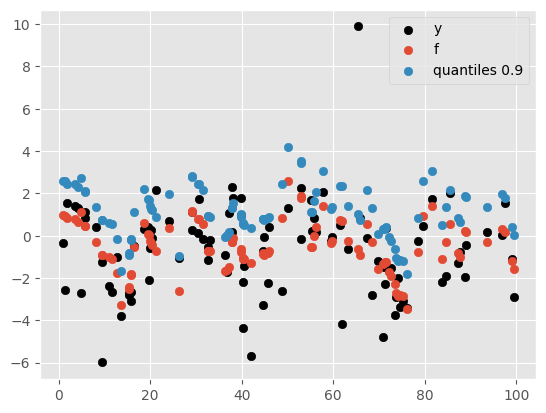

In [27]:
if d == 1:
    plt.scatter(grid, y, color = "black", label = "y")
    plt.scatter(grid, f, label = "f")
    plt.scatter(grid, quantiles, label = f"quantiles {target_quantile}" )
    plt.legend(labelcolor = "black")
    plt.show()
if d == 2:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(grid[:, 0], grid[:,1], y, cmap='viridis', edgecolor='none')